# RL Agent for Game Playing

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a game-playing RL agent
- Train and evaluate in a game environment

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 5**.

---


## Lesson Brief

This lesson uses a simple game to show why games are one of the clearest environments for reinforcement learning.

Students will see how state, action, reward, and repeated episodes naturally appear in game settings.

Why this matters: game-playing examples make RL concrete and easy to visualize.

This lesson helps students connect abstract RL ideas to visible outcomes.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Nicholas Renotte - "Build an Mario AI Model with Python | Gaming Reinforcement Learning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=2eeYqJ0uBKE)

Why this pick:
- game-focused practical workflow.
- Shows how an RL agent is built around a playable environment, preprocessing, and training loop.
- A strong fit for students connecting RL to actual game-playing agents.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Turn-based environment: players act one after another.
- Opponent effect: another player changes the dynamics.
- Win condition: what counts as success.
- Strategy learning: improving through repeated play.
- Delayed consequence: one move can matter several turns later.

### Quick Check
- Why are games useful for learning RL?
- How do state, action, and reward appear in the game?
- What changes when another player is involved?
- Why can a move be good even if it gives no immediate reward?

### Common Mistakes
- Focusing on game rules but missing RL structure.
- Assuming learning happens instantly.
- Ignoring how the opponent changes the problem.
- Judging moves only by immediate reward instead of long-term position.


## Why Games Are Such a Natural RL Example

Games are one of the clearest ways to teach reinforcement learning because the loop is easy to see:

- observe the board or game state
- choose a move
- see the result
- repeat until the game ends

### What students should notice

A game is not only a set of rules.
It is also a sequential decision process with delayed consequences.

A move can be valuable because it creates a better future position, even if the reward is not immediate.

### Why this matters beyond games

The reason games are useful is not that RL is only for games.
It is that games make the RL structure visible, so students can later transfer the same thinking to robotics, recommendation, and operations problems.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Show text or numbers in the cell output area under the code.
print('✅ Setup complete!')


✅ Setup complete!


## Part 1: Simple Game Environment (Tic-Tac-Toe)


### Step Guide

**What this cell does:** Run this cell once, then read the output before worrying about every line of code.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `TicTacToe` (what it does): Simple Tic-Tac-Toe game environment.
class TicTacToe:
    """Simple Tic-Tac-Toe game environment."""
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Save a value in a name so the next lines can read it.
        self.board = np.zeros((3, 3), dtype=int)

    # Function `reset` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def reset(self):
        # Save a value in a name so the next lines can read it.
        self.board[:] = 0
        # Send a value back to whoever called this function.
        return self.board.copy()

    # Function `available_actions` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def available_actions(self):
        # Send a value back to whoever called this function.
        return [(r, c) for r in range(3) for c in range(3) if self.board[r, c] == 0]

    # Function `step` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, action, player.
    def step(self, action, player=1):
        # Save a value in a name so the next lines can read it.
        r, c = action
        # If the condition is True, run the indented block under this line.
        if self.board[r, c] != 0:
            # Send a value back to whoever called this function.
            return self.board.copy(), -5, True, {"invalid": True}
        # Save a value in a name so the next lines can read it.
        self.board[r, c] = player
        # Unpack the one-step model output from transition(state, action).
        reward = 1 if self.check_winner(player) else 0
        # Save a value in a name so the next lines can read it.
        done = reward == 1 or len(self.available_actions()) == 0
        # Send a value back to whoever called this function.
        return self.board.copy(), reward, done, {"invalid": False}

    # Function `check_winner` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, player.
    def check_winner(self, player):
        # Save a value in a name so the next lines can read it.
        rows = np.any(np.sum(self.board == player, axis=1) == 3)
        # Another assignment—same idea: store a value for the lines below.
        cols = np.any(np.sum(self.board == player, axis=0) == 3)
        # Another assignment—same idea: store a value for the lines below.
        diag1 = np.sum(np.diag(self.board == player)) == 3
        # Another assignment—same idea: store a value for the lines below.
        diag2 = np.sum(np.diag(np.fliplr(self.board == player))) == 3
        # Send a value back to whoever called this function.
        return rows or cols or diag1 or diag2


## Part 2: Q-Learning Agent


### Step Guide

**What this cell does:** Follow the printed section: "Selected opening action:"

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [3]:
# Model definition: this class packages one core RL concept into a reusable object.
# Read its state, methods, and update rules together so the algorithm feels concrete.

# Class `QLearningAgent` (what it does): Minimal Q-learning agent for demonstration only.
class QLearningAgent:
    """Minimal Q-learning agent for demonstration only."""
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, learning_rate, gamma, epsilon.
    def __init__(self, learning_rate=0.1, gamma=0.95, epsilon=0.1):
        # Save a value in a name so the next lines can read it.
        self.learning_rate = learning_rate
        # Another assignment—same idea: store a value for the lines below.
        self.gamma = gamma
        # Another assignment—same idea: store a value for the lines below.
        self.epsilon = epsilon
        # Another assignment—same idea: store a value for the lines below.
        self.q = {}

    # Function `key` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, board.
    def key(self, board):
        # Send a value back to whoever called this function.
        return tuple(board.flatten())

    # Function `select_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, env.
    def select_action(self, env):
        # Save a value in a name so the next lines can read it.
        actions = env.available_actions()
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < self.epsilon:
            # Send a value back to whoever called this function.
            return actions[np.random.randint(len(actions))]
        # Save a value in a name so the next lines can read it.
        state_key = self.key(env.board)
        # Create or choose a variable used in the Bellman warm-up demo.
        values = [self.q.get((state_key, action), 0.0) for action in actions]
        # Send a value back to whoever called this function.
        return actions[int(np.argmax(values))]


# Save a value in a name so the next lines can read it.
env = TicTacToe()
# Another assignment—same idea: store a value for the lines below.
agent = QLearningAgent()
# Create or choose a variable used in the Bellman warm-up demo.
state = env.reset()
# Save a value in a name so the next lines can read it.
action = agent.select_action(env)
# Show text or numbers in the cell output area under the code.
print("Selected opening action:", action)


Selected opening action: (0, 0)


## Real-World Applications

- **Chess/Go**: DeepMind AlphaZero
- **Video Games**: Dota 2, StarCraft II
- **Board Games**: Tic-Tac-Toe, Connect 4, Checkers
- **Puzzle Games**: Rubik's Cube solving

### Why this lesson matters

Games are often the cleanest place to understand RL because the rules are clear,
episodes reset easily, and success is easy to observe.

## Worked Example: Why Games Are Good RL Testbeds

Games are useful in RL because they usually provide:
- clear rules
- a known action space
- easy reset between episodes
- a visible success condition

Below, you will compare a simple game-playing strategy against a random opponent.
The point is not to build AlphaZero here. The point is to see how state,
actions, rewards, and repeated episodes naturally fit the RL setup.

Teaching note: this example is mostly about **problem structure and decision logic**. It should not be presented as a full learned Q-learning or deep-RL game agent.

### Step Guide

**What this cell does:** Define a helper you can read in one place before it is used later.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [4]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

# Function `winning_move` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env, player.
def winning_move(env, player):
    # Start a loop: repeat the indented block once per item in the sequence.
    for action in env.available_actions():
        # Save a value in a name so the next lines can read it.
        board_backup = env.board.copy()
        # Another assignment—same idea: store a value for the lines below.
        _, reward, done, _ = env.step(action, player=player)
        # Another assignment—same idea: store a value for the lines below.
        env.board = board_backup
        # If the condition is True, run the indented block under this line.
        if done and reward == 1:
            # Send a value back to whoever called this function.
            return action
    # Send a value back to whoever called this function.
    return None


# Function `center_then_random` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: env.
def center_then_random(env):
    # If the condition is True, run the indented block under this line.
    if env.board[1, 1] == 0:
        # Send a value back to whoever called this function.
        return (1, 1)
    # Save a value in a name so the next lines can read it.
    actions = env.available_actions()
    # Send a value back to whoever called this function.
    return actions[np.random.randint(len(actions))]


# Function `play_game` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: policy_player.
def play_game(policy_player=1):
    # Save a value in a name so the next lines can read it.
    env = TicTacToe()
    # Execute: env.reset()
    env.reset()
    # Save a value in a name so the next lines can read it.
    current_player = 1

    # Start a loop: repeat the indented block while the condition stays True.
    while True:
        # If the condition is True, run the indented block under this line.
        if current_player == policy_player:
            # Save a value in a name so the next lines can read it.
            action = winning_move(env, current_player)
            # If the condition is True, run the indented block under this line.
            if action is None:
                # Save a value in a name so the next lines can read it.
                action = center_then_random(env)
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = env.available_actions()[np.random.randint(len(env.available_actions()))]

        # Another assignment—same idea: store a value for the lines below.
        _, reward, done, _ = env.step(action, player=current_player)
        # If the condition is True, run the indented block under this line.
        if done:
            # If the condition is True, run the indented block under this line.
            if reward == 1:
                # Send a value back to whoever called this function.
                return current_player
            # Send a value back to whoever called this function.
            return 0
        # Save a value in a name so the next lines can read it.
        current_player = 2 if current_player == 1 else 1


# Another assignment—same idea: store a value for the lines below.
results = {1: 0, 2: 0, 0: 0}
# Start a loop: repeat the indented block once per item in the sequence.
for _ in range(200):
    # Save a value in a name so the next lines can read it.
    winner = play_game(policy_player=1)
    # Another assignment—same idea: store a value for the lines below.
    results[winner] += 1

# Show text or numbers in the cell output area under the code.
print("Results over 200 games:")
# Show text or numbers in the cell output area under the code.
print(" Policy player wins:", results[1])
# Show text or numbers in the cell output area under the code.
print(" Random opponent wins:", results[2])
# Show text or numbers in the cell output area under the code.
print(" Draws:", results[0])

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("Games are useful RL environments because the agent can play many episodes,")
# Show text or numbers in the cell output area under the code.
print("observe wins and losses, and gradually improve its policy from repeated experience.")


Results over 200 games:
 Policy player wins: 186
 Random opponent wins: 7
 Draws: 7

Teaching point:
Games are useful RL environments because the agent can play many episodes,
observe wins and losses, and gradually improve its policy from repeated experience.


In [5]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## Summary

This notebook showed why games are a natural RL application area:

- the state is the board configuration
- actions are legal moves
- rewards can represent wins, losses, or draws
- the environment resets cleanly for repeated practice

### Main takeaway

Game-playing problems make RL ideas concrete because students can easily see how
better decisions lead to better outcomes over many episodes.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


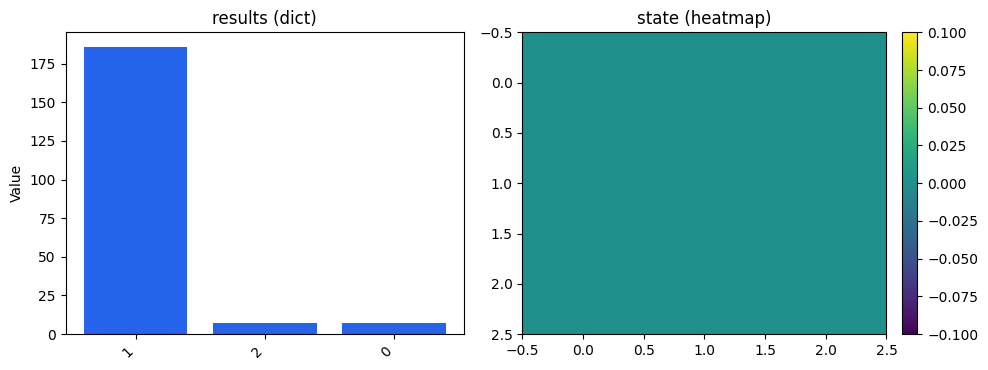

In [6]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Games are useful RL testbeds because actions, feedback, and consequences are easy to observe and discuss clearly.

**If students remember one idea:** Game-playing examples help students see decision quality across many repeated interactions, which is central to RL thinking.

**Quick check before moving on:**
- Can you explain why games are good environments for testing RL ideas?
- Can you describe what makes a game strategy better than a short-term greedy move?

**Bridge to the next step:** After games, students can transfer the same sequential-decision thinking to resource optimization problems.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


objc[41796]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1100f8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1105f49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41796]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1100f8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1105f4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[41796]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1100f7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1105f4a68). T

Motion recap | return=0.0 | frames=14 | term=True | trunc=False


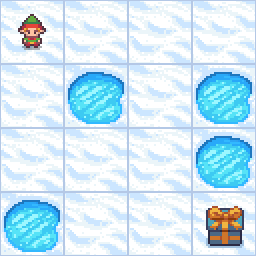

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
